# Hyperparameter Tuning: CNN Traffic Density & Incident Classifier

This notebook conducts a **structured grid search** over the hyperparameter space described in Section 2.5.2 of the project report. Each configuration is trained for **15 epochs** on the training set and validated on the held-out validation set. The best-performing configuration is then retrained from scratch for the full **25 epochs**.

### Search Space

| Hyperparameter | Values Searched |
|---|---|
| Learning rate | 0.001, 0.0005, 0.0001 |
| Batch size | 32, 64, 128 |
| Dropout rate | 0.3, 0.4, 0.5 |
| Optimiser | Adam, SGD w/ Momentum (0.9) |
| Weight decay | 1e-4, 5e-4, 1e-3 |
| LR schedule | CosineAnnealingLR, StepLR, CosineAnnealingWarmRestarts (SGDR) |

## 1. Imports and Setup

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import itertools
import json
import time
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: mps


## 2. Dataset Loading

Augmentation applied **only** to the training split. Validation and test sets use deterministic transforms identical to the baseline. Mixup augmentation (alpha=0.2) is applied inline during the training loop — see Section 5.

In [17]:
data_dir = 'merged_dataset'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names   = image_datasets['train'].classes
num_classes   = len(class_names)

print('Classes:', class_names)
print('Dataset sizes:', dataset_sizes)

Classes: ['heavy', 'incident', 'light', 'moderate']
Dataset sizes: {'train': 3767, 'val': 438, 'test': 417}


## 3. Class-Imbalance Weights

Computed once from the training split and reused across all grid-search runs.

In [18]:
train_labels  = [label for _, label in image_datasets['train'].samples]
class_counts  = Counter(train_labels)
total_samples = sum(class_counts.values())

class_weights = [
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('Class counts:',  dict(zip(class_names, [class_counts[i] for i in range(num_classes)])))
print('Class weights:', dict(zip(class_names, [round(w, 4) for w in class_weights])))

Class counts: {'heavy': 743, 'incident': 210, 'light': 2124, 'moderate': 690}
Class weights: {'heavy': 1.2675, 'incident': 4.4845, 'light': 0.4434, 'moderate': 1.3649}


## 4. Model Architecture

The architecture mirrors the baseline CNN but parameterises the **dropout rate** so it can be varied during the grid search.

In [19]:
class TunableCNN(nn.Module):
    """Baseline CNN with a configurable dropout rate."""

    def __init__(self, num_classes: int = 4, dropout_rate: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),   # → 32×64×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # → 64×32×32
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # → 128×16×16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Quick sanity check
dummy = torch.zeros(2, 3, 128, 128)
test_model = TunableCNN(num_classes=num_classes)
print('Output shape:', test_model(dummy).shape)  # Expected: [2, num_classes]

Output shape: torch.Size([2, 4])


## 5. Helper Functions

### 5.1 Mixup Augmentation

Mixup (Zhang et al., 2018) linearly interpolates pairs of training examples and their labels. When combined with SGDR this encourages the optimiser toward flatter loss-landscape minima.

In [20]:
def mixup_data(x, y, alpha: float = 0.2):
    """Returns mixed inputs, pairs of targets, and the mixing coefficient λ."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

### 5.2 Optimiser & Scheduler Factory

In [21]:
def build_optimizer(model, config: dict):
    """Instantiate optimiser from config dict."""
    lr           = config['lr']
    weight_decay = config['weight_decay']
    opt_name     = config['optimizer']

    if opt_name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == 'SGD':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f'Unknown optimiser: {opt_name}')


def build_scheduler(optimizer, config: dict, num_epochs: int):
    """Instantiate LR scheduler from config dict."""
    schedule = config['lr_schedule']
    lr       = config['lr']

    if schedule == 'CosineAnnealingLR':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    elif schedule == 'StepLR':
        # Decay by 0.1 every 5 epochs
        return optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    elif schedule == 'CosineAnnealingWarmRestarts':
        # T_0=5 → restart every 5 epochs (SGDR, Loshchilov & Hutter, 2017)
        return optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=lr * 0.01)
    else:
        raise ValueError(f'Unknown schedule: {schedule}')

### 5.3 Single Training Run

In [ ]:
def train_one_config(
    config: dict,
    num_epochs: int = 15,
    use_mixup: bool = True,
    mixup_alpha: float = 0.2,
    verbose: bool = True,
):
    """
    Train the TunableCNN for `num_epochs` given a hyperparameter config dict.
    Uses Automatic Mixed Precision (AMP) when running on CUDA (RTX 2070).

    Returns
    -------
    dict : best_val_acc, history (train/val loss + acc per epoch), best_weights
    """
    batch_size   = config['batch_size']
    dropout_rate = config['dropout_rate']

    loaders = {
        split: DataLoader(
            image_datasets[split],
            batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=2,
        )
        for split in ['train', 'val']
    }

    model     = TunableCNN(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, num_epochs)
    scaler    = torch.cuda.amp.GradScaler()                        # AMP scaler

    best_acc    = 0.0
    best_wts    = copy.deepcopy(model.state_dict())
    history     = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        if verbose:
            print(f'  Epoch {epoch+1:02d}/{num_epochs}', end='')

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss     = 0.0
            running_corrects = 0

            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    with torch.autocast(device_type='cuda'):       # AMP forward pass
                        if phase == 'train' and use_mixup:
                            mixed_inputs, y_a, y_b, lam = mixup_data(inputs, labels, alpha=mixup_alpha)
                            outputs = model(mixed_inputs)
                            loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                        else:
                            outputs = model(inputs)
                            loss    = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()              # AMP backward
                        scaler.step(optimizer)                     # AMP optimizer step
                        scaler.update()                            # AMP scaler update
                        optimizer.zero_grad()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = (running_corrects.float() / dataset_sizes[phase]).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())

        history['lr'].append(scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else optimizer.param_groups[0]['lr'])
        scheduler.step()

        if verbose:
            print(f'  →  val_loss={history["val_loss"][-1]:.4f}  val_acc={history["val_acc"][-1]:.4f}')

    return {
        'best_val_acc': best_acc,
        'history':      history,
        'best_weights': best_wts,
    }

## 6. Grid Search

All combinations of the hyperparameter grid are evaluated. Results are logged to `grid_search_results.json` so the search can be resumed if interrupted.

In [23]:
GRID = {
    'lr':           [0.001, 0.0005, 0.0001],
    'batch_size':   [32, 64, 128],
    'dropout_rate': [0.3, 0.4, 0.5],
    'optimizer':    ['Adam', 'SGD'],
    'weight_decay': [1e-4, 5e-4, 1e-3],
    'lr_schedule':  ['CosineAnnealingLR', 'StepLR', 'CosineAnnealingWarmRestarts'],
}

GRID_SEARCH_EPOCHS = 15
RESULTS_FILE       = 'grid_search_results.json'

# Build all combos
keys   = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f'Total configurations: {len(combos)}')

# Load previously saved results if the search was interrupted
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
    print(f'Resuming — {len(all_results)} runs already completed.')
else:
    all_results = []

Total configurations: 486
Resuming — 149 runs already completed.


In [9]:
completed_configs = {json.dumps(r['config'], sort_keys=True) for r in all_results}

for idx, combo in enumerate(combos):
    config = dict(zip(keys, combo))
    config_key = json.dumps(config, sort_keys=True)

    if config_key in completed_configs:
        continue  # Already evaluated

    print(f'\n[{idx+1}/{len(combos)}] Config: {config}')
    t0 = time.time()

    result = train_one_config(config, num_epochs=GRID_SEARCH_EPOCHS, use_mixup=True, verbose=True)

    elapsed = time.time() - t0
    print(f'Best val acc: {result["best_val_acc"]:.4f}  ({elapsed:.0f}s)')

    # Persist (exclude model weights from JSON)
    all_results.append({
        'config':       config,
        'best_val_acc': result['best_val_acc'],
        'history':      {k: v for k, v in result['history'].items()},
        'elapsed_s':    elapsed,
    })
    with open(RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=2)

print('\nGrid search complete.')


[1/486] Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingLR'}
  Epoch 01/15  →  val_loss=0.9488  val_acc=0.5913
  Epoch 02/15  →  val_loss=0.8647  val_acc=0.5936
  Epoch 03/15  →  val_loss=0.7545  val_acc=0.6575
  Epoch 04/15  →  val_loss=0.7133  val_acc=0.7009
  Epoch 05/15  →  val_loss=0.7165  val_acc=0.6689
  Epoch 06/15  →  val_loss=0.5893  val_acc=0.7466
  Epoch 07/15  →  val_loss=0.6685  val_acc=0.6986
  Epoch 08/15  →  val_loss=0.5749  val_acc=0.7671
  Epoch 09/15  →  val_loss=0.5453  val_acc=0.7785
  Epoch 10/15  →  val_loss=0.5303  val_acc=0.7626
  Epoch 11/15  →  val_loss=0.5780  val_acc=0.7580
  Epoch 12/15  →  val_loss=0.5571  val_acc=0.7740
  Epoch 13/15  →  val_loss=0.5294  val_acc=0.7603
  Epoch 14/15  →  val_loss=0.5246  val_acc=0.7694
  Epoch 15/15  →  val_loss=0.5184  val_acc=0.7808
Best val acc: 0.7808  (218s)

[2/486] Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.3, 

KeyboardInterrupt: 

## 7. Results Analysis

### 7.1 Top Configurations

In [24]:
import json
import torch

# ── Load best config from grid search 
with open('grid_search_results.json') as f:
    all_results = json.load(f)

best = max(all_results, key=lambda r: r['best_val_acc'])
best_config = {**best['config']}
best_config['batch_size']   = int(best_config['batch_size'])
best_config['lr']           = float(best_config['lr'])
best_config['weight_decay'] = float(best_config['weight_decay'])
best_config['dropout_rate'] = float(best_config['dropout_rate'])

# ── Full retrain 
FULL_EPOCHS = 25

print(f'Retraining best configuration for {FULL_EPOCHS} epochs...')
print('Config:', best_config)

full_result = train_one_config(
    best_config,
    num_epochs=FULL_EPOCHS,
    use_mixup=True,
    verbose=True,
)

print(f'\nFull retraining complete. Best val acc: {full_result["best_val_acc"]:.4f}')

torch.save(full_result['best_weights'], 'tuned_cnn.pth')
print('Weights saved to tuned_cnn.pth')

Retraining best configuration for 25 epochs...
Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/25  →  val_loss=0.9488  val_acc=0.5913
  Epoch 02/25  →  val_loss=0.7935  val_acc=0.6621
  Epoch 03/25  →  val_loss=0.7568  val_acc=0.6530
  Epoch 04/25  →  val_loss=0.7046  val_acc=0.6735
  Epoch 05/25  →  val_loss=0.7020  val_acc=0.7078
  Epoch 06/25  →  val_loss=0.6664  val_acc=0.7192
  Epoch 07/25  →  val_loss=0.6173  val_acc=0.7329
  Epoch 08/25  →  val_loss=0.6033  val_acc=0.7557
  Epoch 09/25  →  val_loss=0.5343  val_acc=0.7557
  Epoch 10/25  →  val_loss=0.5187  val_acc=0.7785
  Epoch 11/25  →  val_loss=0.6027  val_acc=0.7511
  Epoch 12/25  →  val_loss=0.5271  val_acc=0.7694
  Epoch 13/25  →  val_loss=0.5412  val_acc=0.7466
  Epoch 14/25  →  val_loss=0.4821  val_acc=0.7968
  Epoch 15/25  →  val_loss=0.4661  val_acc=0.8128
  Epoch 16/25  →  val_loss=0.5415  val_acc=0.7831
 

### 7.2 Sensitivity Analysis — Effect of Each Hyperparameter

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, param in enumerate(keys):
    grouped = results_df.groupby(param)['best_val_acc'].agg(['mean', 'max', 'std']).reset_index()
    x_labels = grouped[param].astype(str)
    x_pos    = np.arange(len(x_labels))

    axes[ax].bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=4,
                 color='steelblue', alpha=0.7, label='Mean ± Std')
    axes[ax].scatter(x_pos, grouped['max'], color='darkorange', zorder=5, label='Max')
    axes[ax].set_xticks(x_pos)
    axes[ax].set_xticklabels(x_labels, rotation=20, ha='right', fontsize=8)
    axes[ax].set_title(param, fontweight='bold')
    axes[ax].set_ylabel('Val Accuracy')
    axes[ax].legend(fontsize=7)

plt.suptitle('Hyperparameter Sensitivity — Mean & Max Val Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_sensitivity1.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Learning Curves — Best Configuration (Grid Search Phase)

In [ ]:
# Retrieve history of the best config from all_results
best_config_key = json.dumps(
    {k: best_config[k] for k in keys},
    sort_keys=True
)
best_run = next(
    r for r in all_results
    if json.dumps(r['config'], sort_keys=True) == best_config_key
)
hist = best_run['history']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(hist['train_loss'], label='Train')
ax1.plot(hist['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(hist['train_acc'], label='Train')
ax2.plot(hist['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

ax3.plot(hist['lr'])
ax3.set_title('Learning Rate Schedule'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')

plt.suptitle(f'Best Config — Grid Search (15 epochs)', fontweight='bold')
plt.tight_layout()
plt.savefig('best_config_grid_search_curves1.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full Retraining — Best Configuration (25 Epochs)

The best configuration is retrained from a fresh random initialisation for the full 25 epochs.

In [25]:
FULL_EPOCHS = 25

print(f'Retraining best configuration for {FULL_EPOCHS} epochs...')
print('Config:', best_config)

full_result = train_one_config(
    best_config,
    num_epochs=FULL_EPOCHS,
    use_mixup=True,
    verbose=True,
)

print(f'\nFull retraining complete. Best val acc: {full_result["best_val_acc"]:.4f}')

# Save tuned model weights
torch.save(full_result['best_weights'], 'tuned_cnn_weights -MAC.pth')
print('Weights saved to tuned_cnn_weights.pth')

Retraining best configuration for 25 epochs...
Config: {'lr': 0.001, 'batch_size': 32, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'weight_decay': 0.0001, 'lr_schedule': 'CosineAnnealingWarmRestarts'}
  Epoch 01/25  →  val_loss=0.8816  val_acc=0.6416
  Epoch 02/25  →  val_loss=0.7837  val_acc=0.6347
  Epoch 03/25  →  val_loss=0.6887  val_acc=0.7123
  Epoch 04/25  →  val_loss=0.5577  val_acc=0.7808
  Epoch 05/25  →  val_loss=0.5690  val_acc=0.7626
  Epoch 06/25  →  val_loss=0.6410  val_acc=0.7306
  Epoch 07/25  →  val_loss=0.5525  val_acc=0.7534
  Epoch 08/25  →  val_loss=0.5114  val_acc=0.7763
  Epoch 09/25  →  val_loss=0.4943  val_acc=0.7717
  Epoch 10/25  →  val_loss=0.4822  val_acc=0.7831
  Epoch 11/25  →  val_loss=0.5590  val_acc=0.7763
  Epoch 12/25  →  val_loss=0.5593  val_acc=0.7763
  Epoch 13/25  →  val_loss=0.4964  val_acc=0.7648
  Epoch 14/25  →  val_loss=0.4450  val_acc=0.8174
  Epoch 15/25  →  val_loss=0.4336  val_acc=0.8174
  Epoch 16/25  →  val_loss=0.4930  val_acc=0.7717
 

### 8.1 Full Training Curves

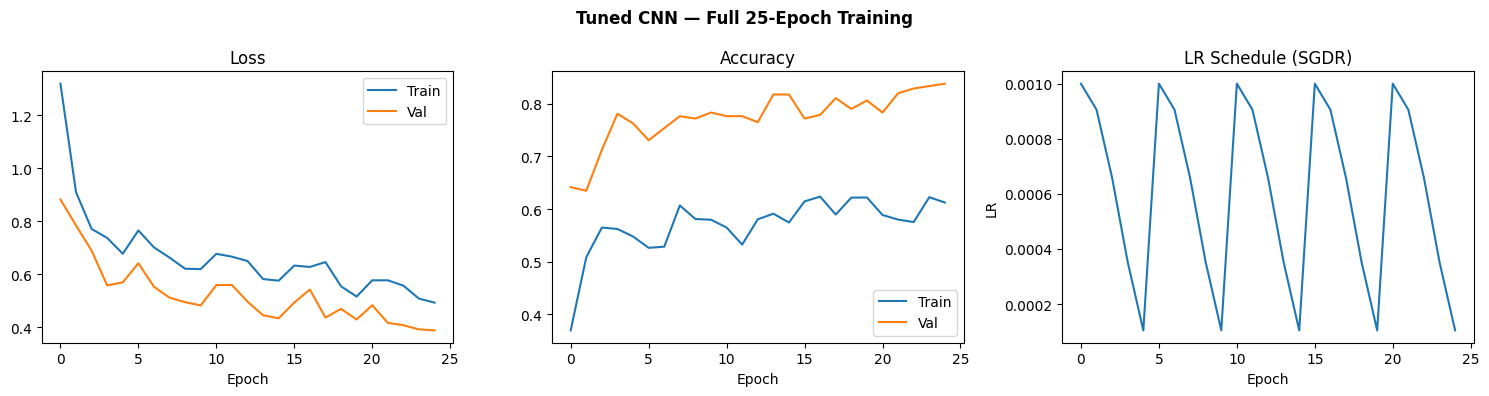

In [26]:
hist_full = full_result['history']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(hist_full['train_loss'], label='Train')
ax1.plot(hist_full['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(hist_full['train_acc'], label='Train')
ax2.plot(hist_full['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

ax3.plot(hist_full['lr'])
ax3.set_title('LR Schedule (SGDR)'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')

plt.suptitle('Tuned CNN — Full 25-Epoch Training', fontweight='bold')
plt.tight_layout()
plt.savefig('tuned_cnn_full_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation

Classification Report:
              precision    recall  f1-score   support

       heavy       0.93      0.86      0.89       167
    incident       0.86      0.86      0.86        56
       light       0.95      0.84      0.89       129
    moderate       0.62      0.89      0.73        65

    accuracy                           0.86       417
   macro avg       0.84      0.86      0.84       417
weighted avg       0.88      0.86      0.86       417



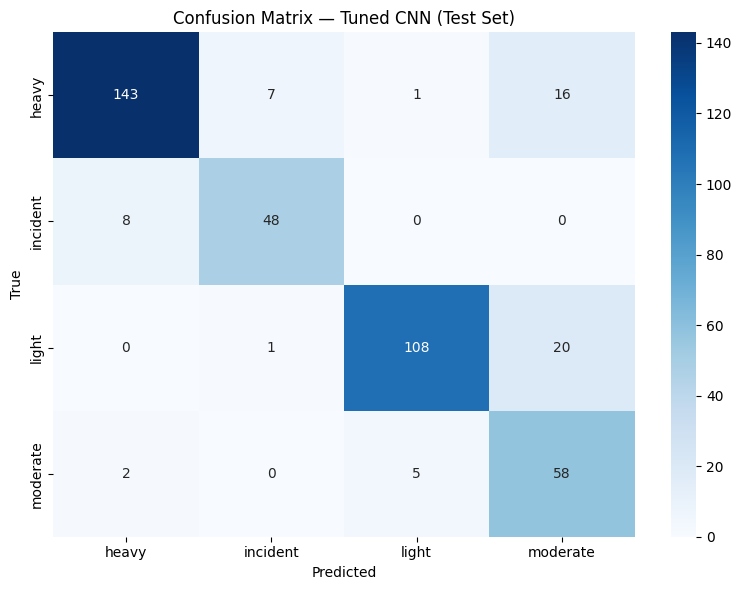

In [27]:
test_loader = DataLoader(
    image_datasets['test'],
    batch_size=best_config['batch_size'],
    shuffle=False,
    num_workers=0,
)

# Rebuild model and load best weights from full retraining
tuned_model = TunableCNN(num_classes=num_classes, dropout_rate=best_config['dropout_rate']).to(device)
tuned_model.load_state_dict(full_result['best_weights'])
tuned_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = tuned_model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Tuned CNN (Test Set)')
plt.tight_layout()
plt.savefig('tuned_cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Baseline vs. Tuned Model — Summary Comparison

In [31]:
# Load baseline results if available (set manually if needed)
# Example: baseline_val_acc = 0.82
baseline_val_acc  = 0.8356  # ← set to the baseline val accuracy from the baseline notebook
baseline_test_acc = None  # ← set to the baseline test accuracy from the baseline notebook

tuned_test_acc = sum(p == t for p, t in zip(y_pred, y_true)) / len(y_true)

print('=' * 45)
print(f"{'Metric':<25} {'Baseline':>8} {'Tuned':>8}")
print('-' * 45)
print(f"{'Val Acc (best config)':<25} {str(baseline_val_acc or 'N/A'):>8} {full_result['best_val_acc']:>8.4f}")
print(f"{'Test Acc':<25} {str(baseline_test_acc or 'N/A'):>8} {tuned_test_acc:>8.4f}")
print('=' * 45)

print('\nBest Hyperparameters Found:')
for k, v in best_config.items():
    print(f'  {k:<20}: {v}')


Metric                    Baseline    Tuned
---------------------------------------------
Val Acc (best config)       0.8356   0.8379
Test Acc                       N/A   0.8561

Best Hyperparameters Found:
  lr                  : 0.001
  batch_size          : 32
  dropout_rate        : 0.3
  optimizer           : Adam
  weight_decay        : 0.0001
  lr_schedule         : CosineAnnealingWarmRestarts


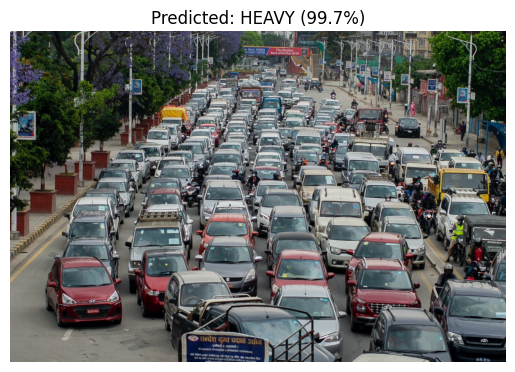

Class Probabilities:
  Heavy: 99.72%
  Incident: 0.01%
  Light: 0.02%
  Moderate: 0.25%


In [34]:
import torch.nn.functional as F
from PIL import Image

def predict_single_image(image_path):
    # Ensure model is in evaluation mode
    tuned_model.eval()
    
    # Load and preprocess the image
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return
        
    # Apply the same validation transforms and add a batch dimension
    input_tensor = data_transforms['val'](image).unsqueeze(0).to(device)
    
    # Run inference
    with torch.no_grad():
        outputs = tuned_model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
        
        confidence, predicted_idx = torch.max(probabilities, 0)
        predicted_class = class_names[predicted_idx]
        
    # Display the picture along with the prediction
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class.upper()} ({confidence.item()*100:.1f}%)")
    plt.show()
    
    # Print out detailed probabilities
    print("Class Probabilities:")
    for i, cls_name in enumerate(class_names):
        print(f"  {cls_name.capitalize()}: {probabilities[i].item() * 100:.2f}%")

# -- Usage --
# Replace with the path to any image you want to test
test_image_path = "test.jpg" # Example path
predict_single_image(test_image_path)
